<a href="https://colab.research.google.com/github/Kylalala13/PEMROGRAMAN/blob/main/Jobsheet_7_AI_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Menentukan Pertanyaan Bisnis
Untuk menganalisis pola penggunaan layanan *bike sharing*, berikut adalah 2 pertanyaan bisnis yang ditetapkan:
1. **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (*weathersit*) terhadap jumlah total penyewaan sepeda harian?
2. **Pertanyaan 2:** Bagaimana perbedaan pola/tren penyewaan sepeda berdasarkan jam (*hr*) dalam sehari antara hari kerja (*workingday*) dan hari libur (*non-workingday*)?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download & Extract dataset resmi Bike Sharing langsung di server Colab
!wget -q https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
!unzip -q -o bike+sharing+dataset.zip

# 2. Baca file CSV
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# 3. Konversi format tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("=== Eksplorasi Pertanyaan 1: Pengaruh Cuaca terhadap Penyewaan Harian ===")
weather_summary = day_df.groupby("weathersit").agg({
    "cnt": ["count", "mean", "min", "max"]
}).reset_index()
print(weather_summary)

print("\n=== Eksplorasi Pertanyaan 2: Rata-Rata Penyewaan per Jam Berdasarkan Hari Kerja ===")
hourly_summary = hour_df.groupby(["workingday", "hr"]).agg({
    "cnt": "mean"
}).reset_index()
print(hourly_summary.head(10))

=== Eksplorasi Pertanyaan 1: Pengaruh Cuaca terhadap Penyewaan Harian ===
  weathersit   cnt                        
             count         mean  min   max
0          1   463  4876.786177  431  8714
1          2   247  4035.862348  605  8362
2          3    21  1803.285714   22  4639

=== Eksplorasi Pertanyaan 2: Rata-Rata Penyewaan per Jam Berdasarkan Hari Kerja ===
   workingday  hr         cnt
0           0   0   90.800000
1           0   1   69.508696
2           0   2   53.171053
3           0   3   25.775330
4           0   4    8.264317
5           0   5    8.689189
6           0   6   18.742358
7           0   7   43.406926
8           0   8  105.653680
9           0   9  171.623377


/tmp/ipykernel_2013/186865907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


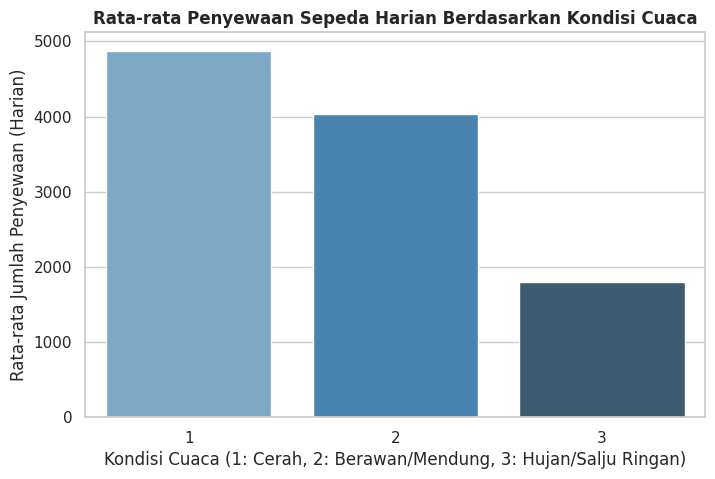

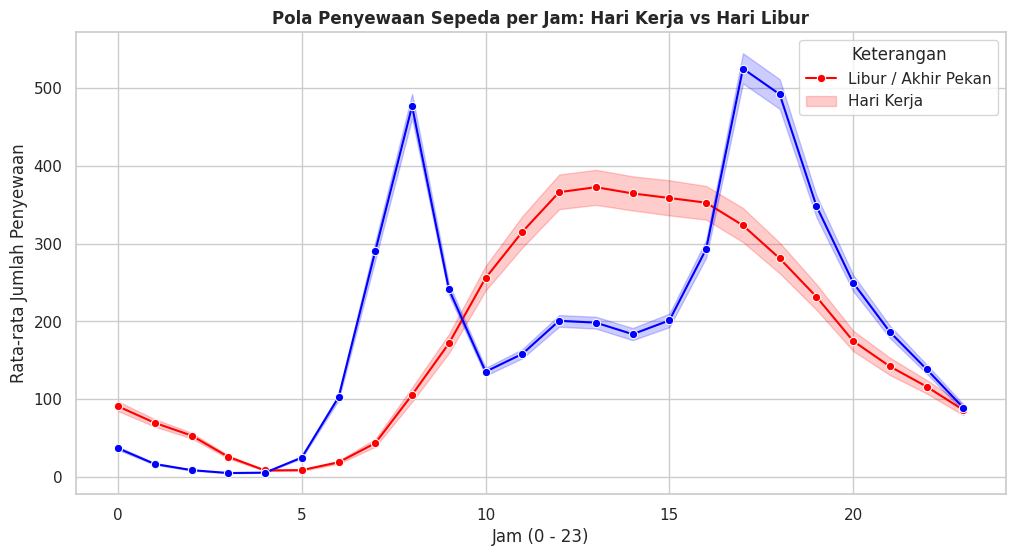

In [2]:
# Set style Seaborn
sns.set_theme(style="whitegrid")

# Visualisasi 1: Barplot Penyewaan berdasarkan Cuaca
plt.figure(figsize=(8, 5))
sns.barplot(
    x="weathersit",
    y="cnt",
    data=day_df,
    palette="Blues_d",
    errorbar=None
)
plt.title("Rata-rata Penyewaan Sepeda Harian Berdasarkan Kondisi Cuaca", fontsize=12, fontweight='bold')
plt.xlabel("Kondisi Cuaca (1: Cerah, 2: Berawan/Mendung, 3: Hujan/Salju Ringan)")
plt.ylabel("Rata-rata Jumlah Penyewaan (Harian)")
plt.show()

# Visualisasi 2: Lineplot Pola Penyewaan per Jam (Hari Kerja vs Hari Libur)
plt.figure(figsize=(12, 6))
sns.lineplot(
    x="hr",
    y="cnt",
    hue="workingday",
    data=hour_df,
    palette={0: "red", 1: "blue"},
    marker="o"
)
plt.title("Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur", fontsize=12, fontweight='bold')
plt.xlabel("Jam (0 - 23)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.legend(title="Keterangan", labels=["Libur / Akhir Pekan", "Hari Kerja"])
plt.show()

# PENUTUP

## Kesimpulan
1. **Pengaruh Kondisi Cuaca:** Kondisi cuaca memengaruhi secara signifikan tingkat penyewaan sepeda. Rata-rata penyewaan tertinggi terjadi pada kondisi cuaca cerah/sedikit berawan (kondisi 1). Sebaliknya, tingkat penyewaan mengalami penurunan tajam saat cuaca memburuk seperti berawan tebal, hujan ringan, atau salju (kondisi 2 dan 3).
2. **Pola Penyewaan pada Hari Kerja:** Pada hari kerja (*workingday*), terdapat dua puncak lonjakan (*rush hour*) penyewaan sepeda yang sangat tajam, yaitu pada pukul **08:00** pagi dan pukul **17:00–18:00** sore. Hal ini menunjukkan bahwa penyewaan sepeda mayoritas dimanfaatkan sebagai moda transportasi komuter untuk berangkat dan pulang kerja/sekolah.
3. **Pola Penyewaan pada Hari Libur:** Pada hari libur/akhir pekan (*non-workingday*), pola penyewaan terdistribusi lebih merata dari siang hingga sore hari (puncak penyewaan pukul **12:00–16:00**). Ini mencerminkan bahwa penggunaan sepeda pada hari libur didominasi oleh aktivitas rekreasi atau olahraga santai.

## Saran
1. **Perawatan Rutin Armada Sepeda:** Manfaatkan hari-hari dengan prediksi cuaca buruk (hujan/salju) untuk melakukan perawatan (*maintenance*) dan inspeksi teknis armada sepeda di bengkel/stasiun, karena permintaan pasar pada hari-hari tersebut relatif sangat rendah.
2. **Redistribusi dan Manajemen Stok Sepeda:** Lakukan penataan ulang (*rebalancing*) unit sepeda di stasiun-stasiun strategis. Pada hari kerja, pastikan stok unit maksimal berada di area pemukiman pada pagi hari (sebelum jam 08:00) dan di area perkantoran/stasiun transit pada sore hari (sebelum jam 17:00).
3. **Strategi Pemasaran dan Promo:** Buat program promo khusus rekreasi atau paket penyewaan berdurasi panjang pada akhir pekan di rentang jam 10:00–16:00 untuk memaksimalkan retensi pengguna non-komuter.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download & Extract dataset resmi Bike Sharing langsung di server Colab
!wget -q https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
!unzip -q -o bike+sharing+dataset.zip

# 2. Baca file CSV yang sudah diekstrak
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

# 3. Konversi format tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

print("✅ Dataset berhasil di-download dan dimuat!")
day_df.head()

✅ Dataset berhasil di-download dan dimuat!


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
# Pengelompokan data berdasarkan kondisi cuaca dan menghitung statistik deskriptif
weather_analysis = day_df.groupby("weathersit").agg({
    "cnt": ["count", "mean", "std", "min", "max"]
}).reset_index()

print("Eksplorasi Penyewaan Sepeda Berdasarkan Cuaca:")
print(weather_analysis)

Eksplorasi Penyewaan Sepeda Berdasarkan Cuaca:
  weathersit   cnt                                     
             count         mean          std  min   max
0          1   463  4876.786177  1879.483989  431  8714
1          2   247  4035.862348  1809.109918  605  8362
2          3    21  1803.285714  1240.284449   22  4639


In [5]:
# Pengelompokan berdasarkan jam (hr) dan status hari kerja (workingday)
hourly_workingday_analysis = hour_df.groupby(["workingday", "hr"]).agg({
    "cnt": "mean"
}).reset_index()

print("Eksplorasi Penyewaan Sepeda Berdasarkan Jam dan Hari Kerja:")
print(hourly_workingday_analysis.head(10))

Eksplorasi Penyewaan Sepeda Berdasarkan Jam dan Hari Kerja:
   workingday  hr         cnt
0           0   0   90.800000
1           0   1   69.508696
2           0   2   53.171053
3           0   3   25.775330
4           0   4    8.264317
5           0   5    8.689189
6           0   6   18.742358
7           0   7   43.406926
8           0   8  105.653680
9           0   9  171.623377


/tmp/ipykernel_2013/3468512400.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_2013/3468512400.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


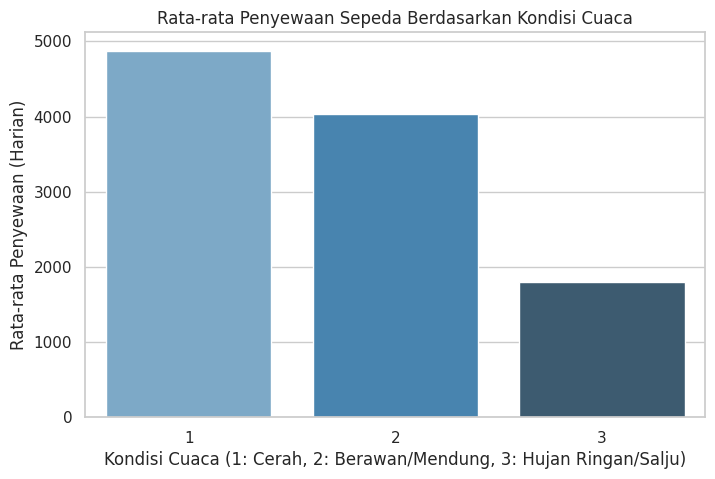

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    x="weathersit",
    y="cnt",
    data=day_df,
    palette="Blues_d",
    ci=None
)
plt.title("Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca")
plt.xlabel("Kondisi Cuaca (1: Cerah, 2: Berawan/Mendung, 3: Hujan Ringan/Salju)")
plt.ylabel("Rata-rata Penyewaan (Harian)")
plt.show()

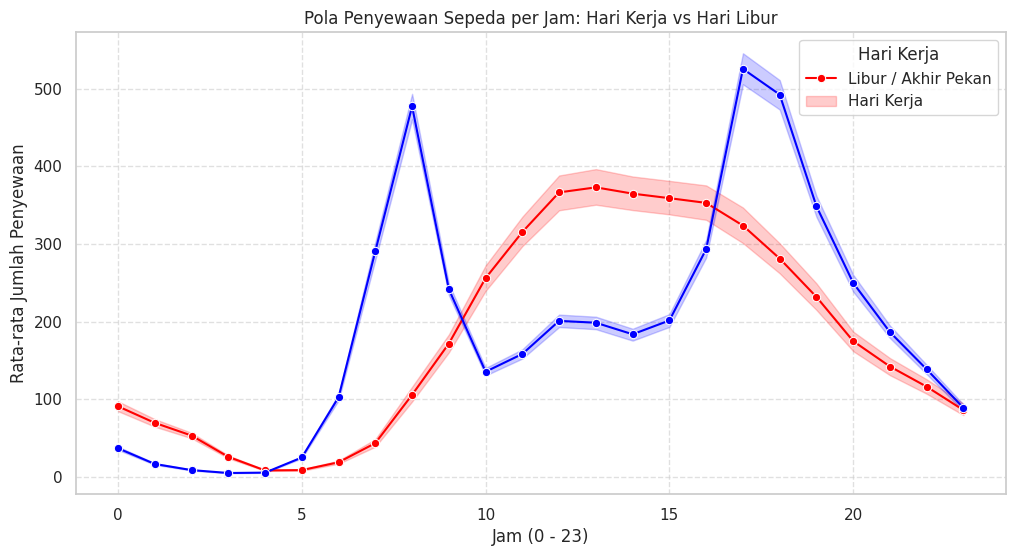

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    x="hr",
    y="cnt",
    hue="workingday",
    data=hour_df,
    palette=["red", "blue"],
    marker="o"
)
plt.title("Pola Penyewaan Sepeda per Jam: Hari Kerja vs Hari Libur")
plt.xlabel("Jam (0 - 23)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.legend(title="Hari Kerja", labels=["Libur / Akhir Pekan", "Hari Kerja"])
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()